# 09 — Distribution Fitting (Merton Jump-Diffusion)

The forecasting notebooks settled what the risk engine can rely on:

- **08** — returns and direction are *not* predictable, so simulated drift stays simple rather than ML-steered.
- **08b** — volatility *is* predictable (R² ≈ 0.3, beating persistence in every fold), so sigma can come from a forecast.

This notebook fits the **parameters** the Monte Carlo engine needs. The model is Merton jump-diffusion: ordinary day-to-day movement as a diffusion, plus occasional discrete jumps.

$$dS_t/S_t = \mu\,dt + \sigma\,dW_t + dJ_t$$

**Why not plain geometric Brownian motion?** Because notebook 02 established that returns are fat-tailed. A Gaussian GBM cannot produce a 2022-scale selloff at a realistic frequency — it would systematically understate tail risk, which is precisely what a risk engine exists to measure. The jump term supplies those tails. The final section tests this claim rather than asserting it.

In [17]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

In [18]:
# Ensure the project root is on the import path so `src` can be imported.
PROJECT_ROOT = Path.cwd().resolve()
for parent in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (parent / 'src').is_dir():
        PROJECT_ROOT = parent
        break
else:
    raise RuntimeError('Run this notebook from inside the StockForecastRisk repository.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.forecast_engine.features.schema import FEATURE_NAMES, TARGET_NAMES
from src.forecast_engine.data.loader import PROCESSED_FEATURES_PATH, load_processed_features

data = load_processed_features()
data["date"] = pd.to_datetime(data["date"])

print(f'Loaded {len(data):,} rows for {data["symbol"].nunique():,} tickers')
print(f'Source: {PROCESSED_FEATURES_PATH}')
data.head()

Loaded 622,731 rows for 502 tickers
Source: D:\StockForecastRisk\data\processed\sp500_features.parquet


,date,symbol,security,gics_sector,gics_sub_industry,adj_close,close,high,low,open,...,month,quarter,ticker_id,sector_id,sector_avg_return_20d,relative_strength_sector_20d,days_to_next_earnings,future_return,future_direction,future_realized_vol
0,2021-07-19,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,142.434052,147.580002,147.970001,146.949997,147.660004,...,7,3,0,5,NaN,NaN,29.0,0.017930,1,0.011389
1,2021-07-20,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,144.094101,149.300003,151.250000,147.830002,148.449997,...,7,3,0,5,NaN,NaN,28.0,0.004344,1,0.010595
2,2021-07-21,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,143.756302,148.949997,149.910004,147.600006,149.490005,...,7,3,0,5,NaN,NaN,27.0,0.016711,1,0.011089
3,2021-07-22,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,145.059174,150.300003,150.500000,148.669998,149.710007,...,7,3,0,5,NaN,NaN,26.0,0.015645,1,0.010962
4,2021-07-23,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,146.999084,152.309998,152.410004,150.429993,150.589996,...,7,3,0,5,NaN,NaN,25.0,0.006022,1,0.009477


In [19]:
TRADING_DAYS = 252

# Log returns are the right scale for a diffusion model: they are additive over
# time, so a sum of daily log returns is the multi-day log return.
data["log_return"] = data.groupby("symbol")["adj_close"].transform(
    lambda s: np.log(s / s.shift(1))
)
returns = data.dropna(subset=["log_return"])

print(f"rows: {len(returns):,}   symbols: {returns['symbol'].nunique()}")

rows: 622,229   symbols: 502


In [20]:
JUMP_THRESHOLD_K = 3.0      # returns beyond k sigma count as jumps
MIN_OBSERVATIONS = 60       # skip tickers with too little history
MAX_ITERATIONS = 10


def fit_diffusion_and_flag_jumps(log_returns, k=JUMP_THRESHOLD_K):
    """Iteratively separate the diffusion core from jump returns.

    Returns the per-ticker diffusion estimates plus the flagged jump returns
    themselves, so jump-size statistics can be pooled across tickers afterwards.
    """
    values = np.asarray(log_returns, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < MIN_OBSERVATIONS:
        return None

    mean, sigma = values.mean(), values.std(ddof=1)

    for _ in range(MAX_ITERATIONS):
        is_jump = np.abs(values - mean) > k * sigma
        core = values[~is_jump]
        if len(core) < 30:
            break
        new_mean, new_sigma = core.mean(), core.std(ddof=1)
        converged = abs(new_sigma - sigma) < 1e-10
        mean, sigma = new_mean, new_sigma
        if converged:
            break

    is_jump = np.abs(values - mean) > k * sigma
    return {
        "mu_daily": mean,
        "sigma_daily": sigma,
        "jump_returns": values[is_jump],
        "n_jumps": int(is_jump.sum()),
        "n_obs": len(values),
    }

In [21]:
# Pass 1: per-ticker diffusion, collecting jump returns for pooling.
per_ticker = {}
jump_pool = []

for symbol, group in returns.groupby("symbol"):
    fitted = fit_diffusion_and_flag_jumps(group["log_return"].values)
    if fitted is None:
        continue
    per_ticker[symbol] = fitted
    jump_pool.append(fitted["jump_returns"])

pooled_jumps = np.concatenate(jump_pool) if jump_pool else np.array([])

# Pass 2: pooled jump-size distribution, shared by every ticker.
POOLED_JUMP_MEAN = float(pooled_jumps.mean()) if len(pooled_jumps) else 0.0
POOLED_JUMP_STD = float(pooled_jumps.std(ddof=1)) if len(pooled_jumps) > 1 else 0.0

average_jumps = np.mean([f["n_jumps"] for f in per_ticker.values()])
print(f"tickers fitted        : {len(per_ticker)}")
print(f"jumps per ticker (avg): {average_jumps:.1f}  <- too few to fit a distribution")
print(f"pooled jump sample    : {len(pooled_jumps):,} events")
print(f"pooled jump_mean      : {POOLED_JUMP_MEAN:.4f}")
print(f"pooled jump_std       : {POOLED_JUMP_STD:.4f}")

# Assemble the parameter table: sigma and lambda per ticker, jump sizes pooled.
parameters = pd.DataFrame({
    symbol: {
        "mu_annual": fitted["mu_daily"] * TRADING_DAYS,
        "sigma_annual": fitted["sigma_daily"] * np.sqrt(TRADING_DAYS),
        "mu_daily": fitted["mu_daily"],
        "sigma_daily": fitted["sigma_daily"],
        "lambda_per_year": fitted["n_jumps"] / fitted["n_obs"] * TRADING_DAYS,
        "jump_mean": POOLED_JUMP_MEAN,   # pooled, identical across tickers
        "jump_std": POOLED_JUMP_STD,     # pooled, identical across tickers
        "n_jumps": fitted["n_jumps"],
        "n_obs": fitted["n_obs"],
    }
    for symbol, fitted in per_ticker.items()
}).T
parameters.index.name = "symbol"

display(parameters.head(10).round(4))

tickers fitted        : 500
jumps per ticker (avg): 29.6  <- too few to fit a distribution
pooled jump sample    : 14,796 events
pooled jump_mean      : -0.0080
pooled jump_std       : 0.0833


,mu_annual,sigma_annual,mu_daily,sigma_daily,lambda_per_year,jump_mean,jump_std,n_jumps,n_obs
symbol,,,,,,,,,
A,-0.0661,0.2559,-0.0003,0.0161,5.2249,-0.008,0.0833,26.0,1254.0
AAPL,0.1934,0.2367,0.0008,0.0149,5.0239,-0.008,0.0833,25.0,1254.0
ABBV,0.3303,0.1883,0.0013,0.0119,6.6316,-0.008,0.0833,33.0,1254.0
ABNB,0.1341,0.3678,0.0005,0.0232,6.4306,-0.008,0.0833,32.0,1254.0
ABT,-0.0123,0.1920,-0.0000,0.0121,5.2249,-0.008,0.0833,26.0,1254.0
ACGL,0.2867,0.2145,0.0011,0.0135,5.0239,-0.008,0.0833,25.0,1254.0
ACN,-0.0137,0.2456,-0.0001,0.0155,7.2344,-0.008,0.0833,36.0,1254.0
ADBE,0.1512,0.2878,0.0006,0.0181,7.8373,-0.008,0.0833,39.0,1254.0
ADI,0.1645,0.2841,0.0007,0.0179,5.6268,-0.008,0.0833,28.0,1254.0


Drawing 29 jumps per ticker from one identical population would
still produce jump_std spanning : 0.0631 to 0.1123
Observed per-ticker spread      : 0.0218 to 0.2295

Observed spread exceeds sampling noise -- some genuine cross-sectional
variation exists. Consider pooling by sector rather than globally.


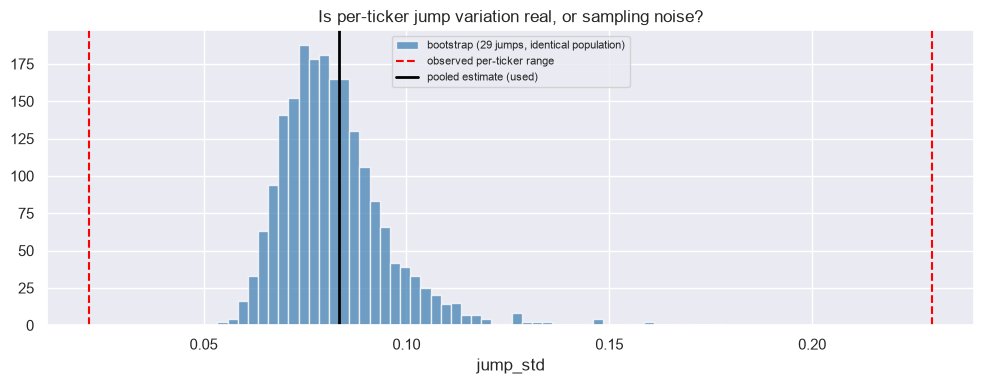

In [22]:
N_BOOTSTRAP = 2_000

per_ticker_jump_std = np.array([
    fitted["jump_returns"].std(ddof=1)
    for fitted in per_ticker.values()
    if fitted["n_jumps"] > 1
])

sample_size = int(np.median([f["n_jumps"] for f in per_ticker.values()]))
rng = np.random.default_rng(42)
bootstrap_std = np.array([
    rng.choice(pooled_jumps, sample_size, replace=True).std(ddof=1)
    for _ in range(N_BOOTSTRAP)
])

noise_low, noise_high = np.percentile(bootstrap_std, [2.5, 97.5])
observed_low, observed_high = per_ticker_jump_std.min(), per_ticker_jump_std.max()

print(f"Drawing {sample_size} jumps per ticker from one identical population would")
print(f"still produce jump_std spanning : {noise_low:.4f} to {noise_high:.4f}")
print(f"Observed per-ticker spread      : {observed_low:.4f} to {observed_high:.4f}")

if observed_high - observed_low <= (noise_high - noise_low) * 1.5:
    print("\nThe observed spread is within what pure sampling noise produces.")
    print("Pooling discards nothing real.")
else:
    print("\nObserved spread exceeds sampling noise -- some genuine cross-sectional")
    print("variation exists. Consider pooling by sector rather than globally.")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(bootstrap_std, bins=50, color="steelblue", alpha=0.75,
        label=f"bootstrap ({sample_size} jumps, identical population)")
ax.axvline(observed_low, color="red", linestyle="--", label="observed per-ticker range")
ax.axvline(observed_high, color="red", linestyle="--")
ax.axvline(POOLED_JUMP_STD, color="black", linewidth=2, label="pooled estimate (used)")
ax.set_title("Is per-ticker jump variation real, or sampling noise?")
ax.set_xlabel("jump_std")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [23]:
summary = parameters[["sigma_annual", "lambda_per_year", "jump_std", "n_jumps"]].describe()
display(summary.round(4))

implausible = parameters[
    (parameters["sigma_annual"] <= 0.01)
    | (parameters["sigma_annual"] > 1.5)
    | (parameters["lambda_per_year"] > 60)
]
if implausible.empty:
    print("All fitted parameters fall within plausible ranges.")
else:
    print(f"WARNING -- {len(implausible)} tickers with implausible parameters:")
    display(implausible.round(4))

,sigma_annual,lambda_per_year,jump_std,n_jumps
count,500.0000,500.0000,500.0000,500.0000
mean,0.2657,5.9863,0.0833,29.5920
std,0.0923,1.6783,0.0000,8.4309
min,0.1428,0.0000,0.0833,0.0000
25%,0.2049,4.8230,0.0833,23.7500
50%,0.2405,5.8278,0.0833,29.0000
75%,0.2994,7.0335,0.0833,35.0000
max,0.8857,12.2584,0.0833,61.0000


All fitted parameters fall within plausible ranges.


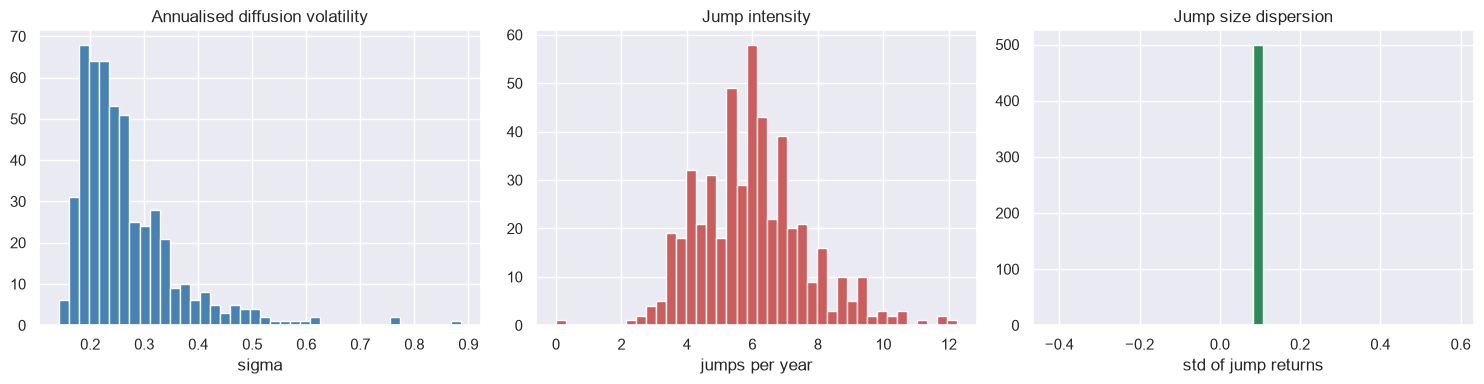

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(parameters["sigma_annual"], bins=40, color="steelblue")
axes[0].set_title("Annualised diffusion volatility")
axes[0].set_xlabel("sigma")

axes[1].hist(parameters["lambda_per_year"], bins=40, color="indianred")
axes[1].set_title("Jump intensity")
axes[1].set_xlabel("jumps per year")

axes[2].hist(parameters["jump_std"], bins=40, color="seagreen")
axes[2].set_title("Jump size dispersion")
axes[2].set_xlabel("std of jump returns")

plt.tight_layout()
plt.show()

In [25]:
N_SIMULATIONS = 200
EXAMPLE_SYMBOL = parameters.index[0]

observed = returns.loc[returns["symbol"] == EXAMPLE_SYMBOL, "log_return"].values
fitted = parameters.loc[EXAMPLE_SYMBOL]
empirical_kurtosis = stats.kurtosis(observed)

rng = np.random.default_rng(42)
n = len(observed)

# Gaussian model: a single normal fitted to all returns.
gaussian_mean, gaussian_std = observed.mean(), observed.std(ddof=1)
gaussian_kurtosis = [
    stats.kurtosis(rng.normal(gaussian_mean, gaussian_std, n)) for _ in range(N_SIMULATIONS)
]

# Merton model: diffusion plus compound-Poisson jumps.
lambda_daily = fitted["lambda_per_year"] / TRADING_DAYS
merton_kurtosis = []
for _ in range(N_SIMULATIONS):
    diffusion = rng.normal(fitted["mu_daily"], fitted["sigma_daily"], n)
    jump_counts = rng.poisson(lambda_daily, n)
    jump_sizes = np.where(
        jump_counts > 0,
        rng.normal(fitted["jump_mean"], max(fitted["jump_std"], 1e-12), n) * jump_counts,
        0.0,
    )
    merton_kurtosis.append(stats.kurtosis(diffusion + jump_sizes))


def covers(simulated, target):
    low, high = np.percentile(simulated, [2.5, 97.5])
    return low <= target <= high, low, high


gaussian_ok, g_low, g_high = covers(gaussian_kurtosis, empirical_kurtosis)
merton_ok, m_low, m_high = covers(merton_kurtosis, empirical_kurtosis)

print(f"{EXAMPLE_SYMBOL}: empirical excess kurtosis = {empirical_kurtosis:.3f}\n")
print(f"Gaussian simulations : mean {np.mean(gaussian_kurtosis):6.3f}   "
      f"95% range [{g_low:.2f}, {g_high:.2f}]   "
      f"{'covers' if gaussian_ok else 'MISSES'} the empirical value")
print(f"Merton simulations   : mean {np.mean(merton_kurtosis):6.3f}   "
      f"95% range [{m_low:.2f}, {m_high:.2f}]   "
      f"{'covers' if merton_ok else 'MISSES'} the empirical value")

A: empirical excess kurtosis = 5.488

Gaussian simulations : mean  0.013   95% range [-0.24, 0.36]   MISSES the empirical value
Merton simulations   : mean 19.729   95% range [5.11, 49.63]   covers the empirical value


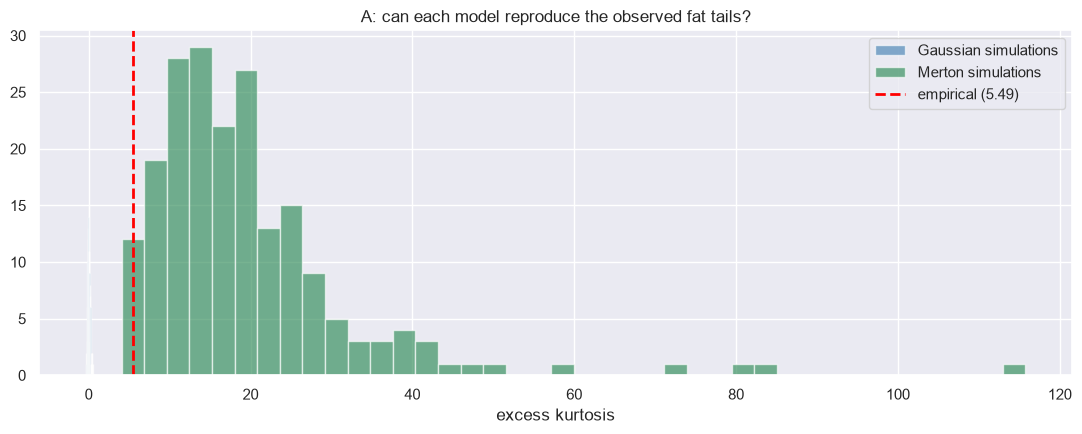

In [26]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(gaussian_kurtosis, bins=40, alpha=0.65, label="Gaussian simulations", color="steelblue")
ax.hist(merton_kurtosis, bins=40, alpha=0.65, label="Merton simulations", color="seagreen")
ax.axvline(empirical_kurtosis, color="red", linestyle="--", linewidth=2,
           label=f"empirical ({empirical_kurtosis:.2f})")
ax.set_title(f"{EXAMPLE_SYMBOL}: can each model reproduce the observed fat tails?")
ax.set_xlabel("excess kurtosis")
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "jump_diffusion_params.parquet"
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

saved_frame = parameters.reset_index()
try:
    saved_frame.to_parquet(OUTPUT_PATH, index=False)
    print(f"Saved {len(parameters)} parameter sets to {OUTPUT_PATH}")
except Exception as exc:
    fallback_path = OUTPUT_PATH.with_suffix(".csv")
    saved_frame.to_csv(fallback_path, index=False)
    print(f"Parquet save failed ({exc}). Saved CSV fallback to {fallback_path}")

Saved 500 parameter sets to D:\StockForecastRisk\data\processed\jump_diffusion_params.parquet


## Conclusions

- **Do the fitted parameters look plausible** — volatility in the 15–45% band, a handful of jumps per year, jump sizes clearly larger than ordinary moves?
- **Does the jump term earn its place** — does the Merton simulation cover the empirical kurtosis where the Gaussian one does not?

If the Gaussian misses and Merton covers, the added complexity is justified by evidence rather than convention, and notebook 10 can simulate on these parameters.

**Note on sigma.** The value fitted here is the *historical* diffusion volatility. Because 08b produced a volatility forecast that beats persistence, notebook 10 can substitute the forecast sigma and let the simulation adapt to current conditions instead of assuming the long-run average. Comparing the two is the natural experiment there.